# EDA — House Prices (Ames Housing)

Goal of this stage: understand the target variable, find missing values, correlations, and outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Target variable: SalePrice

We look at the distribution of the price and its logarithm. We expect right skew, which is the basis for the decision to log-transform the target.

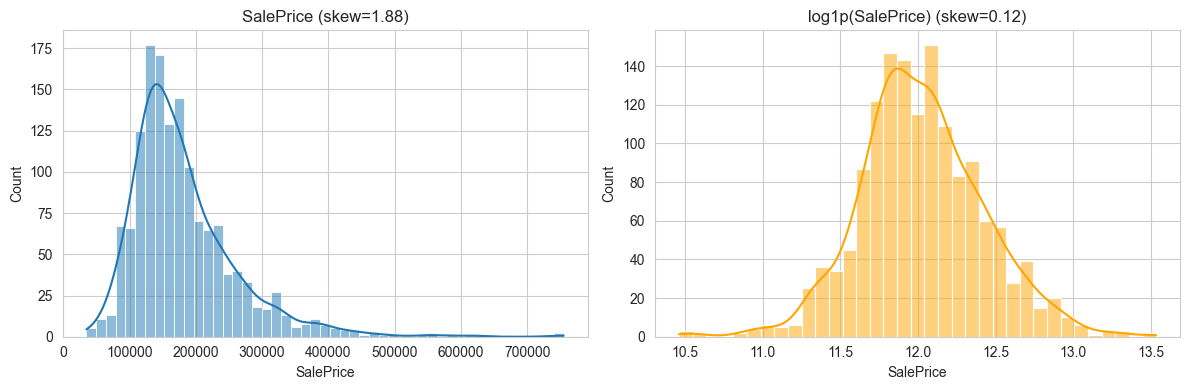

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew={train['SalePrice'].skew():.2f})")

log_price = np.log1p(train["SalePrice"])
sns.histplot(log_price, kde=True, ax=axes[1], color="orange")
axes[1].set_title(f"log1p(SalePrice) (skew={log_price.skew():.2f})")

plt.tight_layout()
plt.show()

train["SalePrice"].describe()

## 2. Missing values

We count the number and share of missing values in every column, for train and test. Many of them are meaningful (e.g. no garage/pool) — we'll handle that at the preprocessing stage; here we just record the list.

In [3]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

missing_df = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 19


,n_missing,pct_missing
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


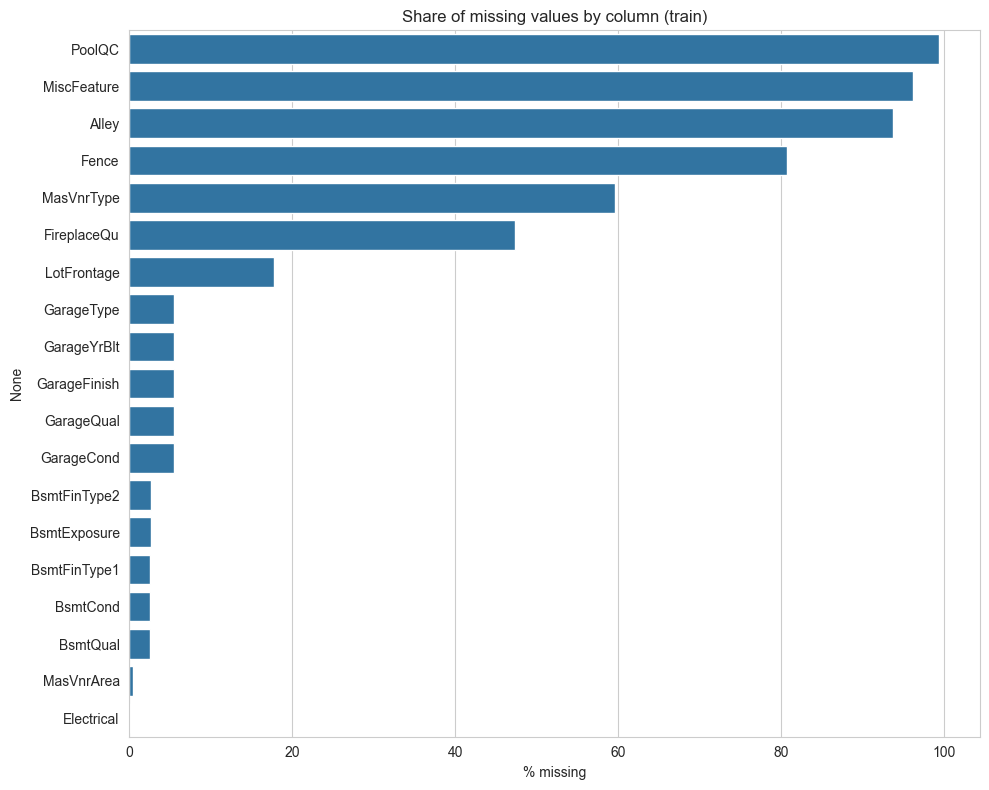

In [4]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_df["pct_missing"], y=missing_df.index)
plt.xlabel("% missing")
plt.title("Share of missing values by column (train)")
plt.tight_layout()
plt.show()

## 3. Correlation of numeric features with price

The features most strongly related to SalePrice — a hint of where to look more closely during feature engineering.

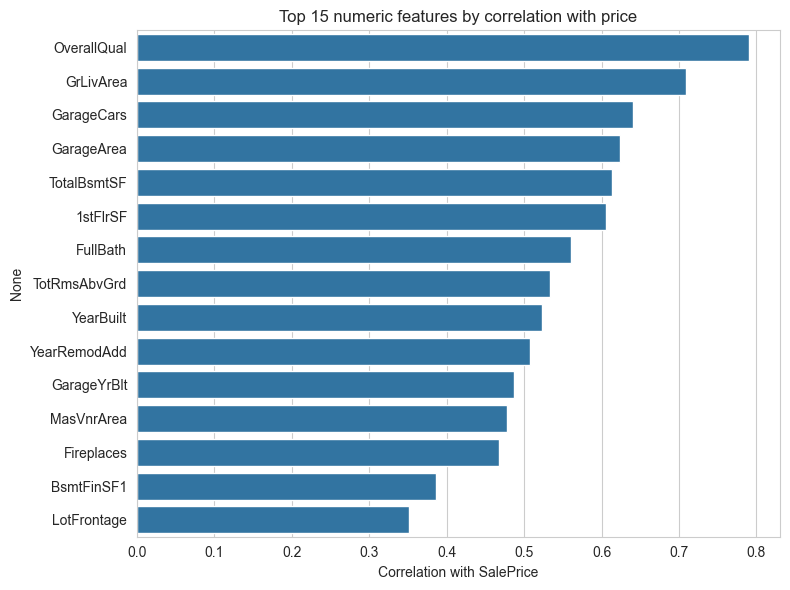

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

In [5]:
numeric = train.select_dtypes(include=[np.number])
corr = numeric.corr()["SalePrice"].sort_values(ascending=False)
top_corr = corr.drop("SalePrice").head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.xlabel("Correlation with SalePrice")
plt.title("Top 15 numeric features by correlation with price")
plt.tight_layout()
plt.show()

top_corr

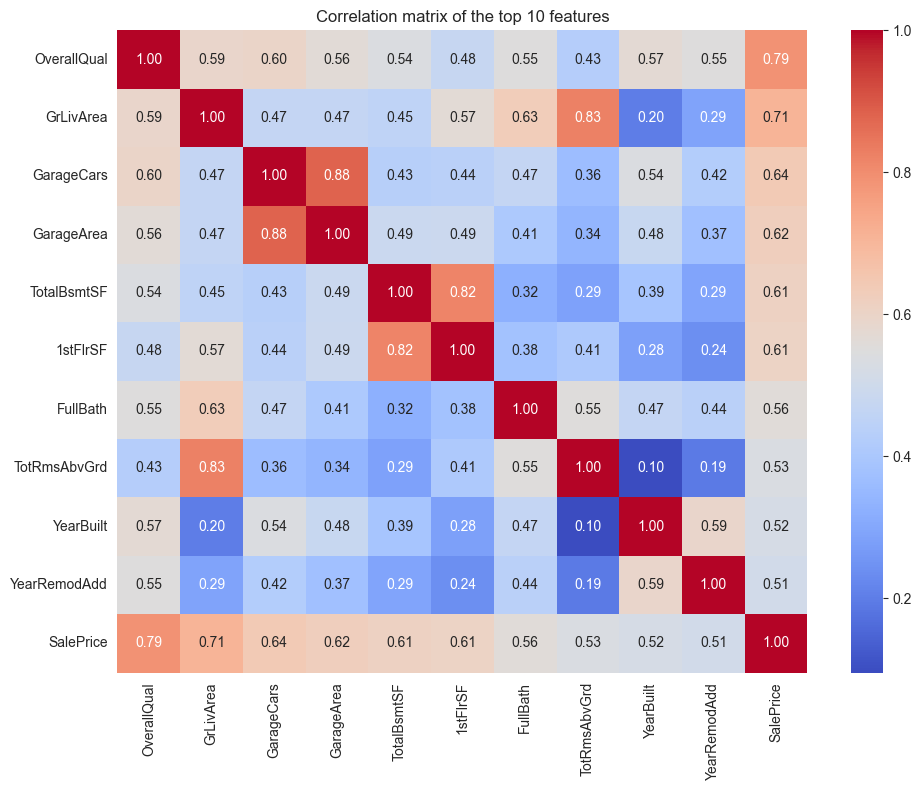

In [6]:
plt.figure(figsize=(10, 8))
top_features = corr.drop("SalePrice").head(10).index.tolist() + ["SalePrice"]
sns.heatmap(train[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix of the top 10 features")
plt.tight_layout()
plt.show()

## 4. Outliers

A classic example from this dataset — homes with a very large living area (GrLivArea) but a suspiciously low price. Let's find and flag them for removal at the preprocessing stage.

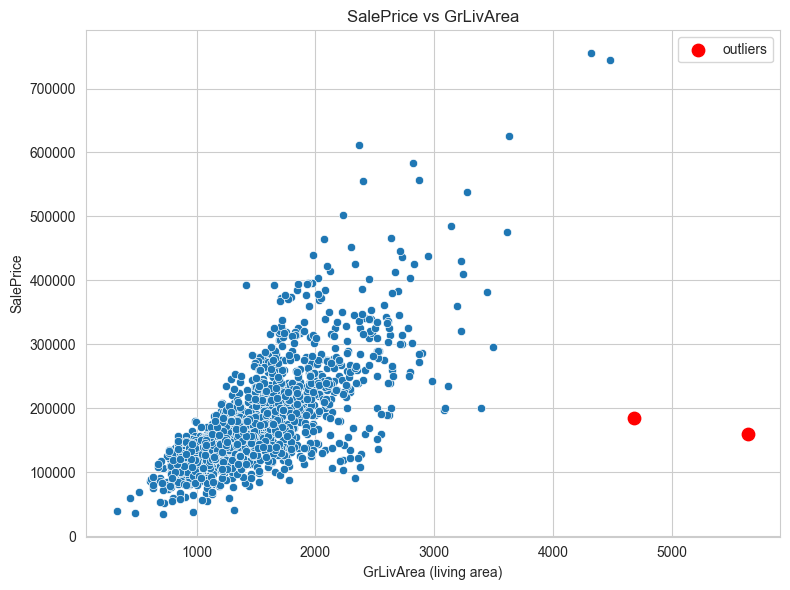

Outliers found: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.xlabel("GrLivArea (living area)")
plt.ylabel("SalePrice")
plt.title("SalePrice vs GrLivArea")

outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
plt.scatter(outliers["GrLivArea"], outliers["SalePrice"], color="red", s=80, label="outliers")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outliers found: {len(outliers)}")
outliers[["Id", "GrLivArea", "SalePrice"]]

## 5. EDA conclusions

1. **SalePrice** is strongly right-skewed (skew ≈ 1.9) — we'll predict `log1p(SalePrice)` instead, which makes the distribution nearly normal (skew ≈ 0.1).
2. **Missing values**: the largest gaps are in `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu` — in most cases NaN means "feature absent" (no pool, no fence, etc.), not lost data. This determines the imputation strategy at the preprocessing stage: `"None"`/`0`, not the median.
3. **Main price drivers** (by correlation): `OverallQual`, `GrLivArea`, `GarageCars`/`GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `YearBuilt` — quality and size matter most. Consistent with the "location, size, quality" expectation.
4. **Outliers**: 2 homes with `GrLivArea > 4000` and a price below 300k — an anomaly relative to the overall trend. We'll drop them before training models.

Next step — preprocessing (`src/preprocessing.py`): filling missing values, feature engineering (`TotalSF`, house age, etc.), encoding categorical features.